In [2]:
import os
import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
from tqdm import tqdm
import time
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# -----------------------------
# 1. Fonctions utilitaires
# -----------------------------
def yolo_to_boxes(yolo_file, img_width, img_height):
    boxes = []
    class_ids = []
    if not os.path.exists(yolo_file):
        return boxes, class_ids
    with open(yolo_file, 'r') as f:
        for line in f.readlines():
            class_id, x_center, y_center, w, h = map(float, line.strip().split())
            x_center *= img_width
            y_center *= img_height
            w *= img_width
            h *= img_height
            xmin = max(x_center - w/2, 0)
            ymin = max(y_center - h/2, 0)
            xmax = min(x_center + w/2, img_width)
            ymax = min(y_center + h/2, img_height)
            if xmax <= xmin or ymax <= ymin:
                continue
            boxes.append([xmin, ymin, xmax, ymax])
            class_ids.append(int(class_id))
    return boxes, class_ids

def boxes_to_masks(boxes, img_height, img_width):
    masks = []
    for box in boxes:
        mask = np.zeros((img_height, img_width), dtype=np.uint8)
        xmin, ymin, xmax, ymax = map(int, box)
        mask[ymin:ymax, xmin:xmax] = 1
        masks.append(mask)
    return masks

# -----------------------------
# 2. Dataset personnalisé YOLO
# -----------------------------
class SARD2YOLODataset(Dataset):
    def __init__(self, images_dir, labels_dir, transforms=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transforms = transforms
        self.images = sorted([f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        label_path = os.path.join(self.labels_dir, self.images[idx].replace('.jpg', '.txt').replace('.png', '.txt'))

        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Image introuvable : {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W, _ = img.shape

        boxes, class_ids = yolo_to_boxes(label_path, W, H)

        if len(boxes) == 0:
            return None

        masks = boxes_to_masks(boxes, H, W)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(class_ids, dtype=torch.int64) + 1  # +1 car 0 = fond
        masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)

        target = {"boxes": boxes, "labels": labels, "masks": masks}
        img = F.to_tensor(img)
        return img, target

# -----------------------------
# 3. Collate_fn pour DataLoader
# -----------------------------
def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    return tuple(zip(*batch))

# -----------------------------
# 4. Configuration optimisée RTX 3050
# -----------------------------
print("🚀 Configuration pour NVIDIA RTX 3050...")
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

if torch.cuda.is_available():
    print(f"✅ GPU détecté : {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

    # Optimisations pour RTX 3050 (4GB VRAM)
    torch.backends.cudnn.benchmark = True  # Accélération cuDNN
    torch.cuda.empty_cache()  # Libérer la mémoire GPU
else:
    print("⚠️ Aucun GPU détecté, utilisation du CPU")

# Add these settings before model training
# Reduce memory usage settings
BATCH_SIZE = 2  # Reduce batch size further
torch.backends.cudnn.benchmark = False  # Disable cudnn benchmark
torch.backends.cuda.max_split_size_mb = 512  # Limit CUDA memory splits

# -----------------------------
# 5. Initialisation Dataset et DataLoader
# -----------------------------
dataset = SARD2YOLODataset('./dataset/images/train', './dataset/labels/train')

# Batch size réduit pour RTX 3050 (4GB VRAM)
# BATCH_SIZE = 3  # Réduit de 6 à 2 pour éviter les OOM
NUM_WORKERS = 0  # Optimisé pour le chargement parallèle

data_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True,  # Accélère le transfert CPU->GPU
)

print(f"📊 Dataset : {len(dataset)} images")
print(f"📦 Batch size : {BATCH_SIZE}")

# -----------------------------
# 6. Définir le modèle Mask R-CNN
# -----------------------------
print("\n🔧 Initialisation du modèle Mask R-CNN...")

# IMPORTANT : Vérifiez le nombre de classes dans votre dataset !
# Pour SARD2, regardez dans vos fichiers .txt la valeur maximale de class_id
# Puis définissez : num_classes = max_class_id + 2 (pour inclure le fond)
# Exemple : si vous avez des class_id de 0 à 4, alors num_classes = 6

def infer_max_class(labels_dir):
    max_id = -1
    for fn in os.listdir(labels_dir):
        if not fn.endswith('.txt'):
            continue
        with open(os.path.join(labels_dir, fn), 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cid = int(float(parts[0]))
                if cid > max_id:
                    max_id = cid
    return max_id

# auto-compute num_classes from label files (safe)
detected_max = infer_max_class('./dataset/labels/train')
print("Detected max class id:", detected_max)
num_classes = detected_max + 2  # +1 for background +1 because class ids are 0-based in YOLO
print("Using num_classes =", num_classes)

# Quick dataset sanity checks (first N samples)
for i in range(min(50, len(dataset))):
    item = dataset[i]
    if item is None:
        continue
    img, target = item
    boxes = target['boxes']
    labels = target['labels']
    masks = target['masks']
    if labels.numel() > 0:
        assert labels.dtype == torch.int64, f"labels dtype must be int64 (sample {i})"
        if labels.max().item() >= num_classes:
            raise ValueError(f"Label out of range in sample {i}: max label {labels.max().item()}, num_classes {num_classes}")
    if boxes.numel() > 0:
        if (boxes[:, 2] <= boxes[:, 0]).any() or (boxes[:, 3] <= boxes[:, 1]).any():
            raise ValueError(f"Invalid box (xmax<=xmin or ymax<=ymin) in sample {i}")
    if masks.ndim != 3 or masks.shape[0] != boxes.shape[0]:
        raise ValueError(f"Mask/box count mismatch in sample {i}: masks {masks.shape}, boxes {boxes.shape}")
print("Dataset sanity checks passed (sampled checks)")

# Run a single forward on CPU to get a Python exception (clear stacktrace)
model_cpu = maskrcnn_resnet50_fpn(pretrained=True)
in_features = model_cpu.roi_heads.box_predictor.cls_score.in_features
model_cpu.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
in_features_mask = model_cpu.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model_cpu.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
model_cpu.train()  # in training mode to use targets -> returns loss dict
dl = DataLoader(dataset, batch_size=1, collate_fn=collate_fn, num_workers=0)
batch = next(iter(dl))
if batch is not None:
    imgs, targets = batch
    imgs = [img.to('cpu') for img in imgs]
    targets = [{k: v.to('cpu') for k, v in t.items()} for t in targets]
    try:
        loss_dict = model_cpu(imgs, targets)
        print("CPU forward OK, losses:", {k: float(v) for k,v in loss_dict.items()})
    except Exception as e:
        print("CPU forward raised:", repr(e))

# Now create the actual model on the correct device
model = maskrcnn_resnet50_fpn(pretrained=True)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
model.to(device)

# Mode d'entraînement mixte précision pour RTX 3050
scaler = torch.cuda.amp.GradScaler()  # Pour l'entraînement en précision mixte (FP16)

# -----------------------------
# 7. Optimiseur
# -----------------------------
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=0.0003, weight_decay=0.0005)  # AdamW plus stable

# Learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# -----------------------------
# 8. Entraînement avec suivi temps réel
# -----------------------------
num_epochs = 1

print(f"\n🎯 Début de l'entraînement sur {num_epochs} epochs\n")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    batch_count = 0

    # Barre de progression pour l'epoch
    pbar = tqdm(data_loader,
                desc=f"Epoch {epoch+1}/{num_epochs}",
                ncols=100,
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]')

    start_time = time.time()

    # Replace the training loop section with this optimized version
    for batch_idx, batch in enumerate(pbar):
        if batch is None:
            continue

        # Clear memory before each batch
        torch.cuda.empty_cache()

        try:
            imgs, targets = batch
            imgs = list(img.to(device) for img in imgs)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # Entraînement en précision mixte (FP16)
            with torch.cuda.amp.autocast():
                loss_dict = model(imgs, targets)
                losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad(set_to_none=True)  # More efficient than zero_grad()
            scaler.scale(losses).backward()
            scaler.step(optimizer)
            scaler.update()

            # Explicitly clear some variables
            del imgs, targets, loss_dict
            torch.cuda.empty_cache()

        except RuntimeError as e:
            if "out of memory" in str(e):
                print(f"WARNING: out of memory error on batch {batch_idx}")
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                continue
            else:
                raise e

        epoch_loss += losses.item()
        batch_count += 1

        # Mise à jour de la barre de progression avec les métriques
        avg_loss = epoch_loss / batch_count
        pbar.set_postfix({
            'Loss': f'{avg_loss:.4f}',
            'Batch Loss': f'{losses.item():.4f}'
        })

    epoch_time = time.time() - start_time
    avg_epoch_loss = epoch_loss / batch_count if batch_count > 0 else 0

    # Mise à jour du learning rate
    lr_scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print(f"✅ Epoch {epoch+1}/{num_epochs} terminée | "
          f"Loss: {avg_epoch_loss:.4f} | "
          f"Temps: {epoch_time:.1f}s | "
          f"LR: {current_lr:.6f}")

    # Sauvegarde périodique
    if (epoch + 1) % 5 == 0:
        checkpoint_path = f"mask_rcnn_checkpoint_epoch_{epoch+1}.pth"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_epoch_loss,
        }, checkpoint_path)
        print(f"💾 Checkpoint sauvegardé : {checkpoint_path}")

# -----------------------------
# 9. Sauvegarde du modèle final
# -----------------------------
torch.save(model.state_dict(), "mask_rcnn_sard2_yolo_final.pth")
print("\n✅ Modèle entraîné et sauvegardé avec succès !")
print(f"📁 Fichier : mask_rcnn_sard2_yolo_final.pth")

🚀 Configuration pour NVIDIA RTX 3050...
✅ GPU détecté : NVIDIA GeForce RTX 3050 Laptop GPU
💾 VRAM disponible : 4.29 GB
📊 Dataset : 1386 images
📦 Batch size : 2

🔧 Initialisation du modèle Mask R-CNN...
Detected max class id: 5
Using num_classes = 7
Dataset sanity checks passed (sampled checks)
CPU forward OK, losses: {'loss_classifier': 1.888283610343933, 'loss_box_reg': 0.15793558955192566, 'loss_mask': 1.3642451763153076, 'loss_objectness': 0.008432291448116302, 'loss_rpn_box_reg': 0.0008415046031586826}


C:\Users\ac223162\AppData\Local\Temp\ipykernel_14448\3221990614.py:218: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # Pour l'entraînement en précision mixte (FP16)



🎯 Début de l'entraînement sur 1 epochs



Epoch 1/1:   0%|                                                            | 0/693 [00:00<?, ?it/s]C:\Users\ac223162\AppData\Local\Temp\ipykernel_14448\3221990614.py:263: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/1: 100%|██████████████████████████████████████████████████| 693/693 [10:13<00:00,  1.13it/s]


✅ Epoch 1/1 terminée | Loss: 0.7454 | Temps: 613.9s | LR: 0.000300

✅ Modèle entraîné et sauvegardé avec succès !
📁 Fichier : mask_rcnn_sard2_yolo_final.pth


C:\Users\ac223162\AppData\Local\Temp\ipykernel_14448\2987152676.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(WEIGHT_PATH, map_location=device)
C:\

Detections:
 - laying_down  | 87.0%
 - Walking  | 80.7%
 - Walking  | 70.1%
 - stands  | 60.6%


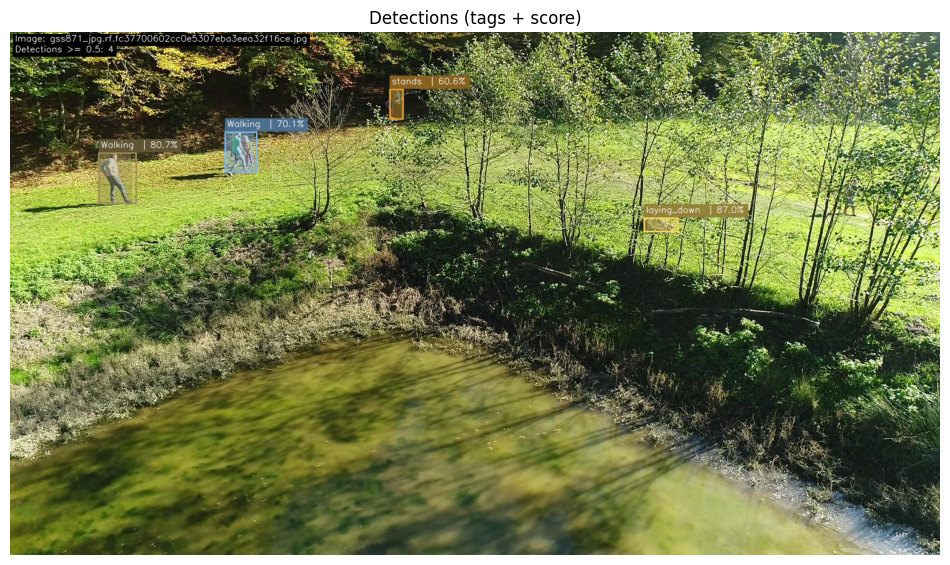

In [8]:
# ...existing code...
# Cell: inference améliorée — tags FR + score lisible + fond de texte
import os, random, cv2, numpy as np, matplotlib.pyplot as plt, torch, torchvision, yaml
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms import functional as F

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
WEIGHT_PATH = "mask_rcnn_sard2_yolo_final.pth"
SCORE_THRESH = 0.5
MASK_THRESH = 0.5
random.seed(42)

# load names from data.yaml
try:
    with open("data.yaml","r") as f:
        meta = yaml.safe_load(f)
        names = meta.get("names", None)
except Exception:
    names = None
if names is None:
    names = ['Running','Walking','laying_down','not_defined','seated','stands']


# pick random image
if 'dataset' in globals():
    images_dir = getattr(dataset,'images_dir','./dataset/images/train')
    images_list = getattr(dataset,'images', sorted([f for f in os.listdir(images_dir) if f.endswith(('.jpg','.png'))]))
else:
    images_dir = './dataset/images/train'
    images_list = sorted([f for f in os.listdir(images_dir) if f.endswith(('.jpg','.png'))])

if len(images_list)==0:
    raise FileNotFoundError(f"Aucune image dans {images_dir}")
img_name = random.choice(images_list)
img_path = os.path.join(images_dir, img_name)
orig_bgr = cv2.imread(img_path)
if orig_bgr is None:
    raise FileNotFoundError(img_path)
orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
h,w = orig_rgb.shape[:2]

# rebuild model
nc = len(names) + 1
model = maskrcnn_resnet50_fpn(pretrained=False)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, nc)
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(in_features_mask, 256, nc)

state = torch.load(WEIGHT_PATH, map_location=device)
if isinstance(state, dict) and 'model_state_dict' in state:
    model.load_state_dict(state['model_state_dict'])
else:
    model.load_state_dict(state)
model.to(device); model.eval()

# inference
img_tensor = F.to_tensor(orig_rgb).to(device)
with torch.no_grad():
    if device.type=='cuda':
        with torch.cuda.amp.autocast():
            outputs = model([img_tensor])
    else:
        outputs = model([img_tensor])

out = outputs[0]
boxes = out.get('boxes', torch.empty((0,4))).cpu()
labels = out.get('labels', torch.empty((0,), dtype=torch.int64)).cpu()
scores = out.get('scores', torch.empty((0,))).cpu()
masks = out.get('masks', torch.empty((0,1,h,w))).cpu()

keep = (scores >= SCORE_THRESH).nonzero(as_tuple=False).squeeze(1)
# prepare drawing canvas in BGR for cv2
canvas_bgr = cv2.cvtColor(orig_rgb, cv2.COLOR_RGB2BGR).copy()

dets_info = []
for i in (keep.tolist() if keep.numel()>0 else []):
    score = float(scores[i].item())
    box = boxes[i].numpy().astype(int)
    lbl = int(labels[i].item()) - 1
    name = names[lbl] if 0<=lbl<len(names) else f"cls_{labels[i].item()}"
    x1,y1,x2,y2 = box
    color = tuple(np.random.randint(0,256,3).tolist())  # BGR
    # mask blending
    if masks.shape[0] > i:
        mask = masks[i,0].numpy()
        mask_bin = mask > MASK_THRESH
        alpha = 0.45
        for c in range(3):
            canvas_bgr[:,:,c] = np.where(mask_bin, (1-alpha)*canvas_bgr[:,:,c] + alpha*color[c], canvas_bgr[:,:,c])
    # draw bbox
    cv2.rectangle(canvas_bgr, (x1,y1), (x2,y2), color, 2, lineType=cv2.LINE_AA)
    # build label text
    text = f"{name}  | {score*100:.1f}%"
    font = cv2.FONT_HERSHEY_SIMPLEX
    fs = 0.6
    th = 2
    (tw,tht), baseline = cv2.getTextSize(text, font, fs, th)
    # label background rectangle (placed above bbox if possible)
    ry1 = max(y1 - tht - baseline - 8, 0)
    rx1 = x1
    rx2 = min(x1 + tw + 10, canvas_bgr.shape[1]-1)
    ry2 = ry1 + tht + baseline + 6
    # filled rectangle with bbox color but darker for contrast
    bg = tuple(max(0, int(c*0.6)) for c in color)
    cv2.rectangle(canvas_bgr, (rx1, ry1), (rx2, ry2), bg, -1, lineType=cv2.LINE_AA)
    # put white text
    text_pos = (rx1 + 4, ry2 - baseline - 3)
    cv2.putText(canvas_bgr, text, text_pos, font, fs, (255,255,255), 1, cv2.LINE_AA)
    dets_info.append({'text':text, 'bbox':box, 'score':score})

# draw legend (top-left) with counts
legend_lines = [f"Image: {img_name}", f"Detections >= {SCORE_THRESH}: {len(dets_info)}"]
for idx, line in enumerate(legend_lines):
    font = cv2.FONT_HERSHEY_SIMPLEX; fs = 0.6
    (tw,tht), baseline = cv2.getTextSize(line,font,fs,1)
    lx1, ly1 = 6, 6 + idx*(tht+8)
    lx2, ly2 = lx1 + tw + 8, ly1 + tht + baseline + 4
    cv2.rectangle(canvas_bgr, (lx1, ly1), (lx2, ly2), (0,0,0), -1)
    cv2.putText(canvas_bgr, line, (lx1+4, ly2-baseline-3), font, fs, (255,255,255), 1, cv2.LINE_AA)

# console summary
print("Detections:")
for d in dets_info:
    print(" -", d['text'])

# convert to RGB for matplotlib and show
canvas_rgb = cv2.cvtColor(canvas_bgr.astype(np.uint8), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,8))
plt.imshow(canvas_rgb); plt.axis('off'); plt.title("Detections (tags + score)")
plt.show()
# ...existing code...